**1. Import the data into a Jupyter notebook and print the first 5 rows.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df_health = pd.read_csv("Health_Sleep_Statistics.csv")
print(df_health.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Health_Sleep_Statistics.csv'

**2. Retrieve general information about the data using info.**

In [9]:
df_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   User ID                  100 non-null    int64 
 1   Age                      100 non-null    int64 
 2   Gender                   100 non-null    object
 3   Sleep Quality            100 non-null    int64 
 4   Bedtime                  100 non-null    object
 5   Wake-up Time             100 non-null    object
 6   Daily Steps              100 non-null    int64 
 7   Calories Burned          100 non-null    int64 
 8   Physical Activity Level  100 non-null    object
 9   Dietary Habits           100 non-null    object
 10  Sleep Disorders          100 non-null    object
 11  Medication Usage         100 non-null    object
dtypes: int64(5), object(7)
memory usage: 9.5+ KB


**3. Create a set of descriptive statistics for the data.**

print(df_health.describe())

**4. Determine whether the tabular data is TidyData.**

**5. If it is TidyData, explain how it meets each of the 3 traits. If it is not, apply transformations to make it TidyData.**

4. Yes, this tabular data is TidyData

5. It meets the 3 traits of TidyData. That is:

TidyData1: Each column represents exactly one variable of the dataset.
    
The dataset meets this criterion. Each column corresponds to a specific variable.

TidyData2: Each row represents exactly one unique mapping from independent to dependent variables.
Each row uniquely identifies a user and maps their attributes (eg: Age, Gender) to outcomes (eg: Sleep Quality, Daily Steps).

TidyData3: Exactly one table is used for each set of mappings involving the same independent variables.
    
It captures a consistent relationship between user attributes and health metrics in a single table.

**6.	Within your dataset, group the data based upon a variable and calculate 3 different aggregations. If your data are not suitable to grouping, just calculate the 3 aggregations for the whole dataset. What do these aggregations suggest about the data?**

In [18]:
grouped_data = df_health.groupby("Physical Activity Level").agg({"Sleep Quality": "mean", "Daily Steps": "median", "Calories Burned": "std"})
print(grouped_data)

                         Sleep Quality  Daily Steps  Calories Burned
Physical Activity Level                                             
high                          8.555556       9000.0       110.590048
low                           4.615385       3500.0        57.779421
medium                        7.157895       6500.0       190.809461


When I grouped the dataset by physical activity level and calculated three different aggregations: the average of sleep quality, median of daily steps, and standard deviation of calories burned, the results reveal the following insights:

**Average of Sleep Quality and Physical Activity Level:**
Higher physical activity levels are associated with better sleep quality, as individuals who engage in more physical activity tend to experience  experience deeper and better sleep.
In contrast, low physical activity levels are linked to poorer sleep quality, highlighting the importance of regular exercise for better rest.

**Median of Daily Steps and Physical Activity Level:**
Individuals with higher physical activity levels consistently achieve more daily steps, reflecting an active and healthy lifestyle.
On the other hand, those with low physical activity levels average only 3,500 steps per day, showing a more inactive lifestyle.

**Standard Deviation of Calories Burned and Physical Activity Level:**
The medium physical activity group shows the highest variation in calories burned, suggesting that this group includes individuals with inconsistent exercise habits or varying body compositions.
In contrast, the low physical activity group has minimal variation, indicating consistently low calorie expenditure.

**7. Create two different types of visualizations with your dataset. These must be different kinds of visualizations (ex. scatterplot and histogram, not two histograms). Label them appropriately. Outline what they mean.**

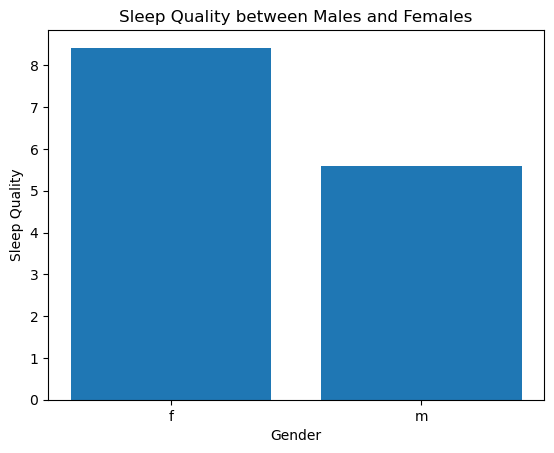

In [39]:
#The bar chart comparing sleep quality between males and females:
gender_grouped = df_health.groupby('Gender')['Sleep Quality'].mean().reset_index()
plt.bar(gender_grouped['Gender'], gender_grouped['Sleep Quality'])
plt.title('Sleep Quality between Males and Females')
plt.xlabel('Gender')
plt.ylabel('Sleep Quality')
plt.show()

We can see that Female report significantly better sleep quality (around 8) compared to Male (around 6). This indicates that sleep issues are more common among Male.

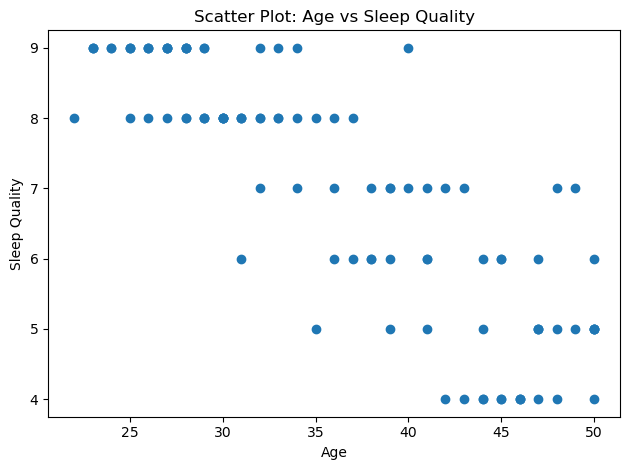

In [45]:
plt.scatter(df_health['Age'], df_health['Sleep Quality'])
plt.title('Scatter Plot: Age vs Sleep Quality')
plt.xlabel('Age')
plt.ylabel('Sleep Quality')
plt.tight_layout()
plt.show()

We can see that based on the scatter plot, there appears to be a negative relationship between Age and Sleep Quality. As age increases, sleep quality tends to decrease. While there is some variability in the data, the overall pattern suggests that older individuals are more likely to report lower sleep quality compared to younger individuals. However, the relationship is not perfectly linear, meaning other factors might also influence sleep quality beyond age alone.

**8. Examining your data and determine if a relationship exists between two of the variables. If your data are not suited to that task, determine if a general trend or pattern is present. Write up your findings (250 words).**

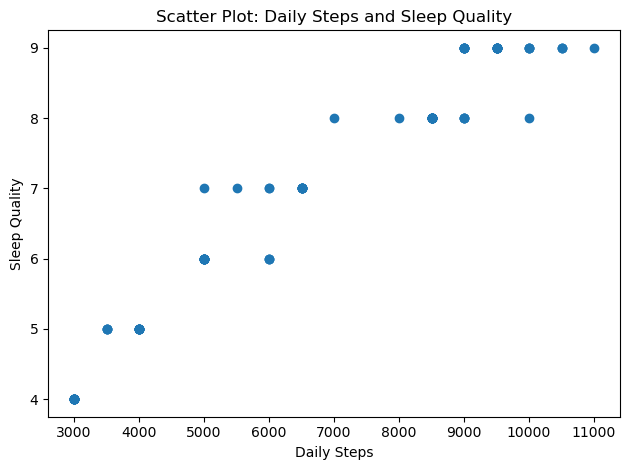

In [51]:
plt.scatter(df_health['Daily Steps'], df_health['Sleep Quality'])
plt.title('Scatter Plot: Daily Steps and Sleep Quality')
plt.xlabel('Daily Steps')
plt.ylabel('Sleep Quality')
plt.tight_layout()
plt.show()

**Relationship between daily steps and sleep quality:**

In analyzing the sleep quality in this dataset, I see a moderate positive correlation exists between daily steps and sleep quality. As individuals take more steps, they tend to report better sleep quality. This trend is supported by a scatterplot I visualized above, where the data points generally align in an upward direction, indicating that higher step counts correspond to improved sleep quality.

Looking at the scatterplot above, I see some statistical trends:

- Individuals who take fewer than 5,000 steps per day tend to report lower sleep quality scores (around 4 to 6).

- Those who take 7,000 or more steps daily frequently report higher sleep quality ratings (ranging from 7 to 9).

- The clustering of data points suggests a consistent positive relationship, though some variability exists.

The scatter plot suggests a clear relationship between physical activity and sleep quality. Increased step counts may contribute to improved sleep, possibly due to the beneficial effects of exercise on sleep regulation. However, I think that correlation does not imply causation, and other factors such as stress levels, diet, or sleep disorders could also influence sleep quality.

In conclusion, the data supports the notion that increased daily steps are generally associated with higher sleep quality. Therefore, encouraging physical activity may be beneficial for improving sleep health. 

This dataset also have more relationships between variables (eg: age vs sleep quality, age vs daily steps, sleep quality vs calories burned,..).We can also create a correlation matrix (heatmap) to visualize relationships between all numerical variables in the dataset. This will help identify strong positive or negative correlations between variables.

**9. Evaluate based upon the current methods how confident you can be with this hypothesis and map out some next steps of how you might go about more credibly (150 words).**

Based on the scatterplot analysis, I can be moderately confident that a relationship exists between Daily Steps and Sleep Quality. However, to strengthen my argument and ensure the credibility of my findings, I can take the following steps:

1. I can conduct more statistical tests to further analyze the relationship between Daily Steps and Sleep Quality such as the correlation coefficient to measure the strength and direction of the association. Additionally, running a simple linear regression analysis and examing key statistical mesures such as SER nad R^2 will help determine whether Daily Steps significantly predict Sleep Quality 

2. By incorporating these variables in the datasets such as: age, dietary habits, sleep disorders, and medication usage into the analysis, I can assess whether the relationship between Daily Steps and Sleep Quality remains significant after controlling for potential confounders. Additionally, I can investigate whether this relationship varies based on demographic factors like age and gender to identify potential interaction effects.




**10.	Write a brief statement on what additional data you may need in your analysis. Where could you possibly locate it? (100 words)**

Although the dataset provides key variables such as Daily Steps, Physical Activity Level, Dietary Habits, and Medication Usage to analyze the sleep quality, additional data such as:  stress levels, caffeine intake, sleep environment conditions(eg: noise, light exposure), and heart rate variability could significantly enhance the analysis.

To obtain these insights, potential data sources include public health datasets, such as IH sleep studies, which offer broader insights into sleep behavior. Additionally, creating self-reported surveys could capture more individualized data, while exploring further sleep studies or health research databases could deepen the analysis with a wider range of sleep behavior patterns.